<a href="https://colab.research.google.com/github/shahwaiz-9/Deep-Learning/blob/main/U_Net_(_CNN_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.layers import (
    Input,
    Dense,
    GlobalAveragePooling2D,
    Concatenate,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

In [2]:
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 256
BATCH = 16


In [3]:
dataset, info = tfds.load(
    "oxford_iiit_pet:4.*.*",
    with_info=True,
    as_supervised=False,
    split=["train", "test"],
)
train_ds, test_ds = dataset


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.AT7FP3_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.AT7FP3_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [4]:
def relabel_mask(mask):
    mask = tf.cast(mask, tf.int32)
    mask = mask - 1  # 1,2,3 → 0,1,2
    mask = tf.clip_by_value(mask, 0, 2)
    return mask


In [5]:
def preprocess(example):
    image = example["image"]
    mask  = example["segmentation_mask"]

    # Remap mask
    mask = relabel_mask(mask)

    # Resize
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    mask  = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method="nearest")

    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # # Squeeze mask to (H, W)
    # mask = tf.squeeze(mask, axis=-1)

    return image, mask


In [6]:
# Since each case has 200 images we should augment data
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    return image, mask


In [7]:
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment,  num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [8]:
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [9]:
# Logic to re construct the image ( We will dive deep into this )

def upsample_block(x, skip, filters, name=""):
    x = layers.Conv2DTranspose(
        filters, 2, strides=2, padding="same", name=f"{name}_up")(x)
    x = layers.concatenate([x, skip], axis=-1, name=f"{name}_concat")
    x = basic_features(x, filters, name=name)
    return x

In [10]:
def basic_features(x , filters, activation = 'relu', padding = 'same', name = ""):
  base_name = name if name else "feature_block"

  x = layers.Conv2D(filters, (3 , 3), padding = padding, name = f"{base_name}_{filters}_conv2D_1")(x)
  x = layers.BatchNormalization(name = f"{base_name}_{filters}_batch_norm_1")(x)
  x = layers.Activation('relu', name = f"{base_name}_{filters}_activation_1")(x)

  x = layers.Conv2D(filters, ( 3 , 3 ), padding = padding, name = f"{base_name}_{filters}_conv2D_2")(x)
  x = layers.BatchNormalization(name = f"{base_name}_{filters}_batch_norm_2")(x)
  x = layers.Activation('relu', name = f"{base_name}_{filters}_activation_2")(x)

  return x

In [15]:
def build_model(input_shape=(256, 256, 3)):
  input = layers.Input(input_shape, name = "input")


  # Encoding

  c1 = basic_features(input, 32, "enc1")
  p1 = layers.MaxPooling2D(2, name = "enc1_pooling")(c1)

  c2 = basic_features(p1, 64, "enc2")
  p2 = layers.MaxPooling2D((2, 2), name= "enc2_pooling")(c2)


  c3 = basic_features(p2, 128, "enc3")
  p3 = layers.MaxPooling2D((2, 2), name= "enc3_pooling")(c3)

  c4 = basic_features(p3, 256, "enc4")
  p4 = layers.MaxPooling2D((2, 2), name= "enc4_pooling")(c4)

  c5 = basic_features(p4, 512, "enc5")
  p5 = layers.MaxPooling2D((2, 2), name= "enc5_pooling")(c5)

  bottleneck = basic_features(p5, 1024, "bottleneck")




  # Decoding (constructing boundry and increasing size back)
  u1 = upsample_block(bottleneck, c5, 512, "dec1")
  u2 = upsample_block(u1, c4, 256, "dec2")
  u3 = upsample_block(u2, c3, 128, "dec3")
  u4 = upsample_block(u3, c2, 64, "dec4")
  u5 = upsample_block(u4, c1, 32, "dec5")


  output = layers.Conv2D(3, (1, 1), activation = None, name = "output")(u5)

  return Model(input , output, name  = "U-Net_Arch")


In [17]:
model = build_model()
model.summary()

Model: "U-Net_Arch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_32_c… │ (None, 256, 256,  │        896 │ input[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_32_b… │ (None, 256, 256,  │        128 │ feature_block_32… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_32_a… │ (None, 256, 256,  │          0 │ feature_block_32… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_32_c… │ (None, 256, 256,  │      9,248 │ feature_block_32… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_32_b… │ (None, 256, 256,  │        128 │ feature_block_32… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_32_a… │ (None, 256, 256,  │          0 │ feature_block_32… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_pooling        │ (None, 128, 128,  │          0 │ feature_block_32… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_64_c… │ (None, 128, 128,  │     18,496 │ enc1_pooling[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_64_b… │ (None, 128, 128,  │        256 │ feature_block_64… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_64_a… │ (None, 128, 128,  │          0 │ feature_block_64… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_64_c… │ (None, 128, 128,  │     36,928 │ feature_block_64… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_64_b… │ (None, 128, 128,  │        256 │ feature_block_64… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_64_a… │ (None, 128, 128,  │          0 │ feature_block_64… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_pooling        │ (None, 64, 64,    │          0 │ feature_block_64… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_128_… │ (None, 64, 64,    │     73,856 │ enc2_pooling[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_block_128_… │ (None, 64, 64,    │        512 │ feature_block_12

 Total params: 31,118,627 (118.71 MB)

 Trainable params: 31,106,595 (118.66 MB)

 Non-trainable params: 12,032 (47.00 KB)

In [18]:
model.compile(
    optimizer='adam',
    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["sparse_categorical_accuracy"]
)

In [19]:
model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 210s 608ms/step - loss: 0.6689 - sparse_categorical_accuracy: 0.7209 - val_loss: 3.8879 - val_sparse_categorical_accuracy: 0.6317
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 138s 598ms/step - loss: 0.5111 - sparse_categorical_accuracy: 0.7982 - val_loss: 1.0657 - val_sparse_categorical_accuracy: 0.7445
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 128s 555ms/step - loss: 0.4442 - sparse_categorical_accuracy: 0.8261 - val_loss: 0.5814 - val_sparse_categorical_accuracy: 0.7963
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 138s 598ms/step - loss: 0.3995 - sparse_categorical_accuracy: 0.8451 - val_loss: 0.4524 - val_sparse_categorical_accuracy: 0.8429
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 128s 555ms/step - loss: 0.3664 - sparse_categorical_accuracy: 0.8586 - val_loss: 0.4422 - val_sparse_categorical_accuracy: 0.8433
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 127s 553ms/step - loss: 0.3423 - sparse_categorical_accuracy: 0.8687 - val_loss: 0.6389 - val_sparse_categoric

Overfitting in this as well but the accuracy score is good.

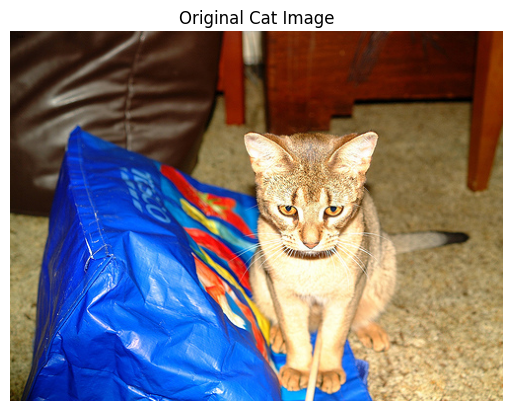

In [20]:
import requests
from PIL import Image
import io

# Path to the cat image in the local directory
image_path = "/content/Abyssinian_105.jpg"

# Load the image
img_raw = Image.open(image_path)

# Convert to RGB (if not already) and display
img_raw = img_raw.convert('RGB')
plt.imshow(img_raw)
plt.title("Original Cat Image")
plt.axis('off')
plt.show()

Now, let's preprocess this image to fit the model's input expectations. We need to resize it and normalize pixel values.

In [21]:
# Preprocess the image
img_tensor = tf.convert_to_tensor(np.array(img_raw), dtype=tf.float32)
img_tensor = tf.image.resize(img_tensor, [IMG_SIZE, IMG_SIZE])
img_tensor = img_tensor / 255.0  # Normalize to [0, 1]
img_tensor = tf.expand_dims(img_tensor, axis=0) # Add batch dimension

print(f"Preprocessed image shape: {img_tensor.shape}")

Preprocessed image shape: (1, 256, 256, 3)


With the image preprocessed, we can now make a prediction using our trained U-Net model.

In [22]:
# Make a prediction
prediction = model.predict(img_tensor)

# The output is logits, apply argmax to get the class labels
predicted_mask = tf.argmax(prediction, axis=-1)
predicted_mask = predicted_mask[0] # Remove batch dimension

print(f"Predicted mask shape: {predicted_mask.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted mask shape: (256, 256)


Finally, let's visualize the original image and its predicted segmentation mask side-by-side.

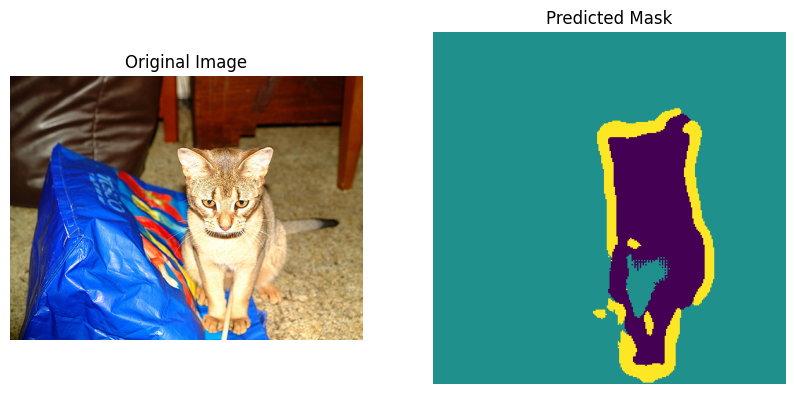

In [23]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_raw)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# For visualization, we often need to ensure the mask is 2D and can use a colormap
plt.imshow(predicted_mask, cmap='viridis')
plt.title('Predicted Mask')
plt.axis('off')

plt.show()

In [ ]:
# for image, mask in train_ds.take(1):
#     for i in range(5):
#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.imshow(image[i])
#         plt.title('Image')
#         plt.axis('off')

#         plt.subplot(1, 2, 2)
#         plt.imshow(mask[i, ..., 0], cmap='viridis') # Squeeze the last dimension for visualization
#         plt.title('Mask')
#         plt.axis('off')
#         plt.show()